# Bài toán Logistic Regression: Dự đoán xác suất thi đỗ dựa trên số giờ học

Khác với Linear Regression trả về một giá trị thực không giới hạn, Logistic Regression thường được dùng cho các bài toán phân lớp. Ở đây, đầu ra của mô hình được đưa qua một hàm kích hoạt để nén giá trị về một khoảng từ 0 đến 1, đại diện cho **xác suất** xảy ra một sự kiện.

Hàm kích hoạt được sử dụng phổ biến nhất là hàm **Sigmoid**:
$$\sigma(s) = \frac{1}{1 + e^{-s}}$$


Trong ví dụ này, chúng ta có dữ liệu của 20 sinh viên, gồm số giờ ôn thi và kết quả (1 là Đỗ, 0 là Trượt). Ta sẽ xây dựng mô hình để tính xác suất thi đỗ của một sinh viên dựa vào số giờ họ học.

In [1]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(2)

# Dữ liệu: X là số giờ học, y là kết quả (0: Trượt, 1: Đỗ)
X = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50,
              2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]])
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

# Mở rộng dữ liệu X bằng cách thêm một hàng toàn số 1 (đại diện cho bias w0)
X = np.concatenate((np.ones((1, X.shape[1])), X), axis = 0)

## Tối ưu hàm mất mát bằng Stochastic Gradient Descent (SGD)

Mục tiêu của chúng ta là đi tìm bộ trọng số $\mathbf{w}$ sao cho hàm mất mát (Negative Log Likelihood / Cross-Entropy) đạt giá trị nhỏ nhất. Do không có công thức nghiệm trực tiếp, bài toán tối ưu này được giải quyết thông qua thuật toán Stochastic Gradient Descent (SGD).

Công thức cập nhật trọng số ở mỗi vòng lặp cực kỳ tinh gọn:
$$\mathbf{w} = \mathbf{w} + \eta(y_i - z_i)\mathbf{x}_i$$

Trong đó:
* $\eta$ (eta) là tốc độ học (learning rate).
* $z_i = \sigma(\mathbf{w}^T\mathbf{x}_i)$ là xác suất đỗ dự đoán của mô hình.
* $y_i$ là nhãn thực tế.

In [2]:
def sigmoid(s):
    return 1/(1 + np.exp(-s))

def logistic_sigmoid_regression(X, y, w_init, eta, tol = 1e-4, max_count = 10000):
    w = [w_init]
    it = 0
    N = X.shape[1]
    d = X.shape[0]
    count = 0
    check_w_after = 20
    while count < max_count:
        # Xáo trộn dữ liệu (mix data) ở mỗi epoch
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[:, i].reshape(d, 1)
            yi = y[i]
            zi = sigmoid(np.dot(w[-1].T, xi))
            w_new = w[-1] + eta*(yi - zi)*xi
            count += 1
            # Điều kiện dừng (stopping criteria)
            if count%check_w_after == 0:
                if np.linalg.norm(w_new - w[-check_w_after]) < tol:
                    return w
            w.append(w_new)
    return w

# Khởi tạo tham số và chạy thuật toán
eta = .05
d = X.shape[0]
w_init = np.random.randn(d, 1)

w = logistic_sigmoid_regression(X, y, w_init, eta)
print('Trọng số w tìm được: \n', w[-1])

# In thử xác suất dự đoán trên chính tập dữ liệu training
print('\nXác suất dự đoán: \n', sigmoid(np.dot(w[-1].T, X)))

Trọng số w tìm được: 
 [[-4.092695  ]
 [ 1.55277242]]

Xác suất dự đoán: 
 [[0.03501592 0.05078108 0.07310642 0.10416972 0.14634799 0.20175793
  0.20175793 0.27147534 0.35458234 0.4475032  0.54424128 0.63775242
  0.72188183 0.79282004 0.89267823 0.92460236 0.94758783 0.96384008
  0.97518471 0.9884283 ]]


## Trực quan hóa kết quả phân lớp

Vector trọng số $\mathbf{w}$ tìm được chứa hai hệ số $w_0$ và $w_1$. Biểu thức dự đoán xác suất có dạng:
$y_{pred} = \sigma(w_0 + w_1 * x)$.


Để dễ dàng đưa ra quyết định "Trượt" hay "Đỗ", ta sẽ dùng ngưỡng xác suất cứng (hard threshold) là $0.5$. Đường gióng màu vàng tương ứng với xác suất $0.5$ chính là điểm phân chia ranh giới giữa hai lớp. Những người học nhiều hơn khoảng thời gian này sẽ được dự đoán là đỗ, và ngược lại.

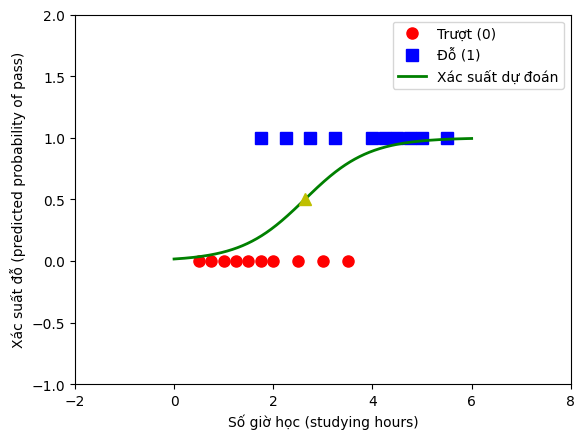

In [3]:
# Tách dữ liệu thực tế thành 2 lớp Trượt (0) và Đỗ (1) để vẽ
X0 = X[1, np.where(y == 0)][0]
y0 = y[np.where(y == 0)]
X1 = X[1, np.where(y == 1)][0]
y1 = y[np.where(y == 1)]

# Vẽ các điểm dữ liệu
plt.plot(X0, y0, 'ro', markersize = 8, label='Trượt (0)')
plt.plot(X1, y1, 'bs', markersize = 8, label='Đỗ (1)')

# Tạo dải dữ liệu x để vẽ đường cong Sigmoid
xx = np.linspace(0, 6, 1000)
w0 = w[-1][0][0]
w1 = w[-1][1][0]
threshold = -w0/w1
yy = sigmoid(w0 + w1*xx)

# Vẽ đường phân phối xác suất dự đoán
plt.axis([-2, 8, -1, 2])
plt.plot(xx, yy, 'g-', linewidth = 2, label='Xác suất dự đoán')

# Vẽ đường phân chia ngưỡng 0.5 (threshold)
plt.plot(threshold, .5, 'y^', markersize = 8)

plt.xlabel('Số giờ học (studying hours)')
plt.ylabel('Xác suất đỗ (predicted probability of pass)')
plt.legend()
plt.show()